**Clasificación y Optimización de Hiperparámetros (Core)**

Descripción del Dataset: El dataset de costos médicos personales contiene información sobre varios factores que afectan los costos de seguros médicos, como la edad, el sexo, el índice de masa corporal, y el hábito de fumar. Este dataset es ideal para practicar técnicas de preprocesamiento y optimización de modelos debido a la presencia de datos sucios y variables tanto categóricas como numéricas.

**1. Carga y Exploración Inicial de Datos:**

1.1. Cargar el dataset desde Kaggle.

1.2. Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.

1.3. Identificar y documentar los valores faltantes y outliers en el dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [3]:
# 1.1. Cargar el dataset desde Kaggle.
df = pd.read_csv('/content/insurance.csv')
print(f'Dataset cargado — shape: {df.shape}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')

Dataset cargado — shape: (1338, 7)
Columnas (7): ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [4]:
# 1.2. Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.
display(df.head())
display(df.tail())
df.info()
display(df.describe())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# 1.3. Identificar y documentar los valores faltantes y outliers en el dataset.
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicados:,}')
print(f'Porcentaje del dataset: {n_duplicados/len(df)*100:.2f}%')

if n_duplicados > 0:
    print('\nEjemplos de filas duplicadas:')
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6))

Filas duplicadas encontradas: 1
Porcentaje del dataset: 0.07%

Ejemplos de filas duplicadas:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [15]:
df = df.drop_duplicates()

Se detectó una única observación duplicada (0,07% del dataset), la cual fue eliminada debido a su escaso impacto en el volumen total de datos y para evitar sesgos en el entrenamiento de los modelos.

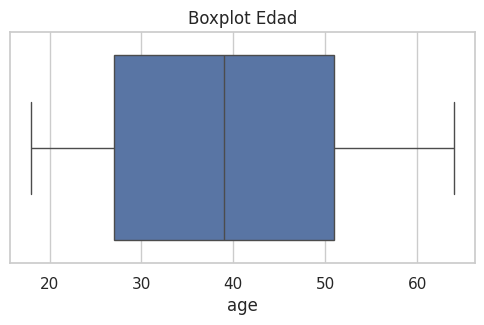

In [16]:
# Identificación de outliers mediante Boxplots
# Boxplot de Age
plt.figure(figsize=(6,3))
sns.boxplot(x=df['age'])
plt.title('Boxplot Edad')
plt.show()

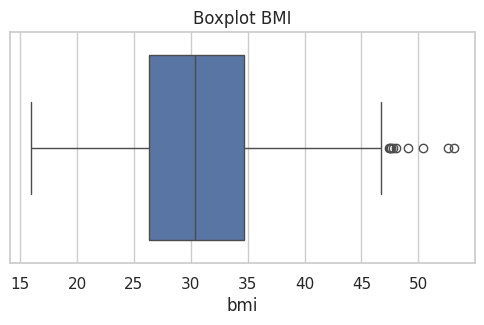

In [17]:
# Boxplot de BMI
plt.figure(figsize=(6,3))
sns.boxplot(x=df['bmi'])
plt.title('Boxplot BMI')
plt.show()


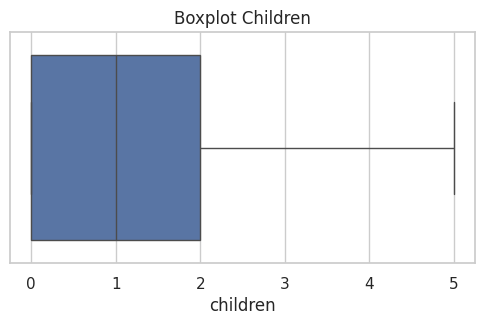

In [18]:
# Boxplot de Children
plt.figure(figsize=(6,3))
sns.boxplot(x=df['children'])
plt.title('Boxplot Children')
plt.show()

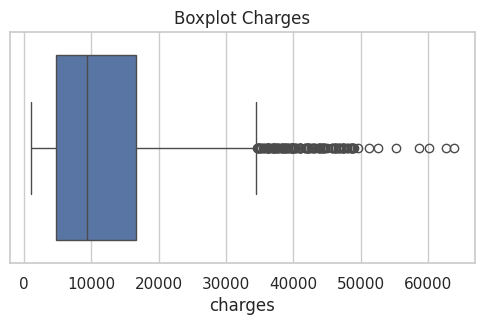

In [19]:
# Boxplot de Charges
plt.figure(figsize=(6,3))
sns.boxplot(x=df['charges'])
plt.title('Boxplot Charges')
plt.show()

In [20]:
# Contar outliers con IQR
for col in ['age','bmi','children','charges']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    print(f'{col}: {len(outliers)} outliers')

age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


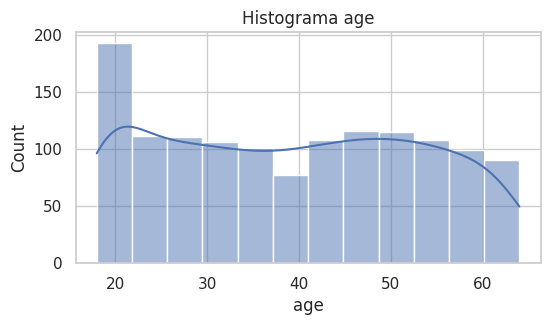

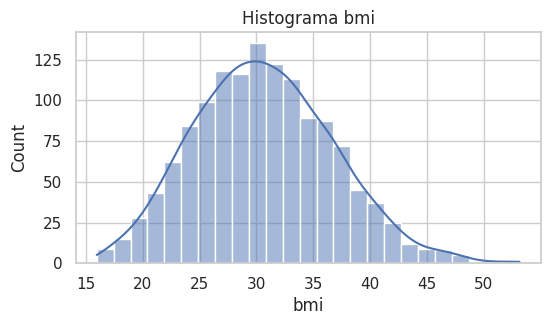

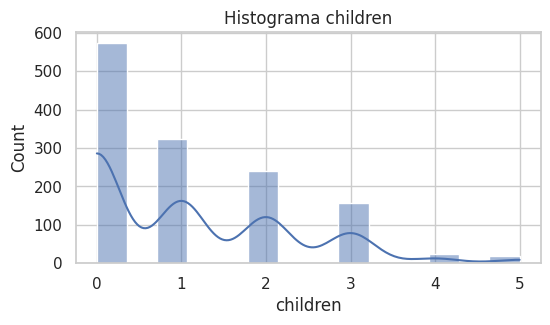

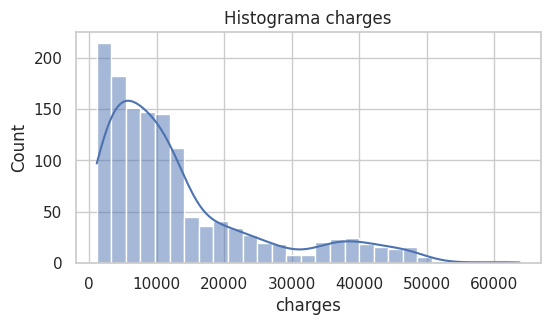

In [21]:
# Histogramas para visualizar distribuciones.
for col in ['age','bmi','children','charges']:
    plt.figure(figsize=(6,3))
    sns.histplot(x=df[col], kde=True)
    plt.title(f'Histograma {col}')
    plt.show()



No eliminar outliers de BMI

Los valores extremos de BMI representan casos reales de pacientes con obesidad severa y pueden aportar información relevante para la predicción de costos médicos.

No eliminar los outliers de Charges

En este dataset esos valores altos suelen corresponder a fumadores, personas con IMC elevado, tratamientos costosos.
Son precisamente los casos que el modelo debe aprender.


In [22]:
df['high_cost'] = np.where(df['charges'] >= df['charges'].median(),1,0)

In [23]:
df['high_cost'].value_counts()

,count
high_cost,
1,669
0,668


El análisis exploratorio mostró que el dataset no presenta valores faltantes y contiene únicamente una observación duplicada, la cual fue eliminada. Se identificaron 9 valores atípicos en la variable BMI y 139 en la variable charges. Tras revisar los histogramas y boxplots, se determinó mantener estos registros debido a que representan casos reales de clientes con altos costos médicos y condiciones particulares de salud, información que resulta relevante para el problema de clasificación y podría mejorar la capacidad predictiva de los modelos.

**2. Preprocesamiento de Datos:**

2.1. Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).

2.2. Codificar variables categóricas utilizando One-Hot Encoding.

2.3. Escalar características numéricas utilizando StandardScaler.

In [33]:
# 2.1. Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).
columnas_numericas = ['age', 'bmi', 'children']
columnas_categoricas = ['sex', 'smoker', 'region']

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [35]:
pipeline_numerico = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

In [36]:
pipeline_categorico = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [37]:
# 2.2. Codificar variables categóricas utilizando One-Hot Encoding.
('onehot', OneHotEncoder(handle_unknown='ignore'))

('onehot', OneHotEncoder(handle_unknown='ignore'))

In [38]:
# 2.3. Escalar características numéricas utilizando StandardScaler.
('scaler', StandardScaler())

('scaler', StandardScaler())

In [39]:
preprocessor = ColumnTransformer([('num', pipeline_numerico, columnas_numericas),('cat', pipeline_categorico, columnas_categoricas)])

In [40]:
X = df.drop(['charges', 'high_cost'], axis=1)
y = df['high_cost']

In [41]:
X_preparado = preprocessor.fit_transform(X)
print(X_preparado.shape)

(1337, 11)


Se aplicó un proceso de preprocesamiento mediante ColumnTransformer, combinando imputación, codificación One-Hot Encoding y escalamiento de variables numéricas. Como resultado, el conjunto de datos quedó transformado en una matriz de 1337 observaciones y 11 características, donde las variables categóricas fueron convertidas en variables binarias y las variables numéricas fueron estandarizadas para facilitar el entrenamiento de los modelos de clasificación.

**3. Implementación de Modelos de Clasificación:**

3.1. Entrenar y evaluar al menos tres modelos de clasificación diferentes: Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.

3.2. Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.


In [48]:
# 3.1. Entrenar y evaluar al menos tres modelos de clasificación diferentes: Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [49]:
X = df.drop(['charges', 'high_cost'], axis=1)
y = df['high_cost']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [53]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1069, 6)
(268, 6)
(1069,)
(268,)


In [59]:
# Regresión Logística
pipeline_lr = Pipeline([('preprocessor', preprocessor),('modelo', LogisticRegression(random_state=42))])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

In [60]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn = Pipeline([('preprocessor', preprocessor),('modelo', KNeighborsClassifier())])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

In [61]:
# Árbol de Decisión
from sklearn.tree import DecisionTreeClassifier

pipeline_tree = Pipeline([('preprocessor', preprocessor),('modelo', DecisionTreeClassifier(random_state=42))])
pipeline_tree.fit(X_train, y_train)
y_pred_tree = pipeline_tree.predict(X_test)

In [64]:
# 3.2. Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.
from sklearn.model_selection import cross_val_score
import numpy as np

In [65]:
# Regresión Logística
scores_lr = cross_val_score(pipeline_lr,X_train,y_train,cv=5,scoring='accuracy')
print("Accuracy Promedio:", np.mean(scores_lr))

Accuracy Promedio: 0.9064674652275022


In [66]:
# KNN
scores_knn = cross_val_score(pipeline_knn,X_train,y_train,cv=5,scoring='accuracy')
print("Accuracy Promedio:", np.mean(scores_knn))


Accuracy Promedio: 0.8821332982317582


In [67]:
# Árbol de Decisión
scores_tree = cross_val_score(pipeline_tree,X_train,y_train,cv=5,scoring='accuracy')
print("Accuracy Promedio:", np.mean(scores_tree))

Accuracy Promedio: 0.8849282611557194


In [69]:
# Tabla comparativa
resultados_cv = pd.DataFrame({'Modelo': ['Regresión Logística','KNN','Árbol de Decisión'],'Accuracy CV': [np.mean(scores_lr),np.mean(scores_knn),np.mean(scores_tree)]})
display(resultados_cv.sort_values('Accuracy CV',ascending=False))

,Modelo,Accuracy CV
0,Regresión Logística,0.906467
2,Árbol de Decisión,0.884928
1,KNN,0.882133


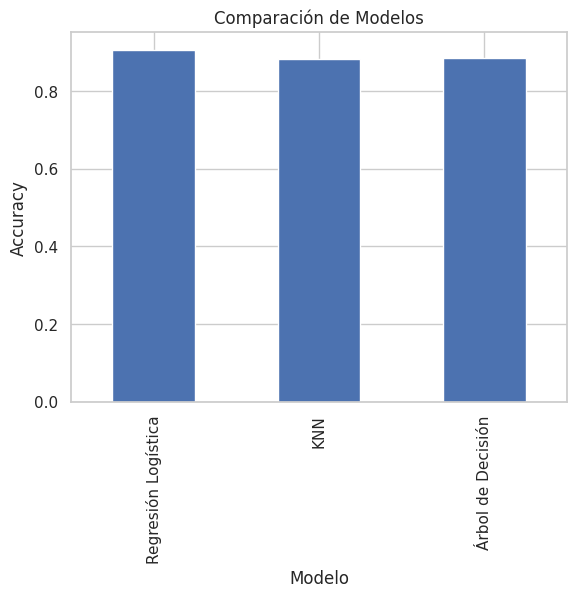

In [70]:
# Gráfico comparativo
resultados_cv.plot(x='Modelo',y='Accuracy CV',kind='bar',legend=False)
plt.title('Comparación de Modelos')
plt.ylabel('Accuracy')
plt.xlabel('Modelo')

plt.show()

En la evaluación inicial mediante validación cruzada, los tres modelos obtuvieron un desempeño alto, con valores de Accuracy superiores al 88%. El mejor modelo fue Regresión Logística, alcanzando un Accuracy promedio de 90,65%, seguido por Árbol de Decisión con 88,49% y KNN con 88,21%.

Esto indica que las variables del dataset permiten distinguir bastante bien entre clientes de alto y bajo costo médico. Además, la Regresión Logística se posiciona como el modelo inicial más prometedor, ya que logra el mejor rendimiento y mantiene una estructura simple e interpretable.

**4. Optimización de Hiperparámetros:**

4.1. Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.

4.2. Implementar RandomizedSearchCV como método alternativo de optimización.

4.3. Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.

In [71]:
# 4.1. Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.
from sklearn.model_selection import GridSearchCV

In [72]:
# Regresión Logística
param_grid_lr = {'modelo__C': [0.01, 0.1, 1, 10],'modelo__max_iter': [1000]}
grid_lr = GridSearchCV(pipeline_lr,param_grid_lr,cv=5,scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Mejores parámetros LR:", grid_lr.best_params_)
print("Mejor Accuracy LR:", grid_lr.best_score_)

Mejores parámetros LR: {'modelo__C': 10, 'modelo__max_iter': 1000}
Mejor Accuracy LR: 0.9083366241060068


In [73]:
# KNN
param_grid_knn = {'modelo__n_neighbors': [3, 5, 7, 9, 11],'modelo__weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(pipeline_knn,param_grid_knn,cv=5,scoring='accuracy')
grid_knn.fit(X_train, y_train)

print("Mejores parámetros KNN:", grid_knn.best_params_)
print("Mejor Accuracy KNN:", grid_knn.best_score_)

Mejores parámetros KNN: {'modelo__n_neighbors': 11, 'modelo__weights': 'distance'}
Mejor Accuracy KNN: 0.8952261857750866


In [74]:
# Árbol de Decisión
param_grid_tree = {'modelo__max_depth': [3, 5, 10, None],'modelo__min_samples_split': [2, 5, 10],'modelo__min_samples_leaf': [1, 2, 4]}
grid_tree = GridSearchCV(pipeline_tree,param_grid_tree,cv=5,scoring='accuracy')
grid_tree.fit(X_train, y_train)

print("Mejores parámetros Árbol:", grid_tree.best_params_)
print("Mejor Accuracy Árbol:", grid_tree.best_score_)

Mejores parámetros Árbol: {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 2}
Mejor Accuracy Árbol: 0.9130007459084727


In [75]:
# 4.2. Implementar RandomizedSearchCV como método alternativo de optimización.
from sklearn.model_selection import RandomizedSearchCV

In [76]:
# Regresión Logística
random_lr = RandomizedSearchCV(pipeline_lr,param_grid_lr,n_iter=4,cv=5,scoring='accuracy',random_state=42)
random_lr.fit(X_train, y_train)

print("Mejores parámetros LR Random:", random_lr.best_params_)
print("Mejor Accuracy LR Random:", random_lr.best_score_)

Mejores parámetros LR Random: {'modelo__max_iter': 1000, 'modelo__C': 10}
Mejor Accuracy LR Random: 0.9083366241060068


In [77]:
# KNN
random_knn = RandomizedSearchCV(pipeline_knn,param_grid_knn,n_iter=5,cv=5,scoring='accuracy',random_state=42)
random_knn.fit(X_train, y_train)

print("Mejores parámetros KNN Random:", random_knn.best_params_)
print("Mejor Accuracy KNN Random:", random_knn.best_score_)

Mejores parámetros KNN Random: {'modelo__weights': 'distance', 'modelo__n_neighbors': 7}
Mejor Accuracy KNN Random: 0.893357026896582


In [78]:
# Árbol de Decisión
random_tree = RandomizedSearchCV(pipeline_tree,param_grid_tree,n_iter=10,cv=5,scoring='accuracy',random_state=42)
random_tree.fit(X_train, y_train)

print("Mejores parámetros Árbol Random:", random_tree.best_params_)
print("Mejor Accuracy Árbol Random:", random_tree.best_score_)

Mejores parámetros Árbol Random: {'modelo__min_samples_split': 5, 'modelo__min_samples_leaf': 4, 'modelo__max_depth': 5}
Mejor Accuracy Árbol Random: 0.9130007459084727


In [79]:
# 4.3. Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.
resultados_opt = pd.DataFrame({'Modelo': ['Regresión Logística','KNN','Árbol de Decisión'],'GridSearchCV': [grid_lr.best_score_,grid_knn.best_score_,grid_tree.best_score_],'RandomizedSearchCV': [random_lr.best_score_,random_knn.best_score_,random_tree.best_score_]})

display(resultados_opt)

,Modelo,GridSearchCV,RandomizedSearchCV
0,Regresión Logística,0.908337,0.908337
1,KNN,0.895226,0.893357
2,Árbol de Decisión,0.913001,0.913001


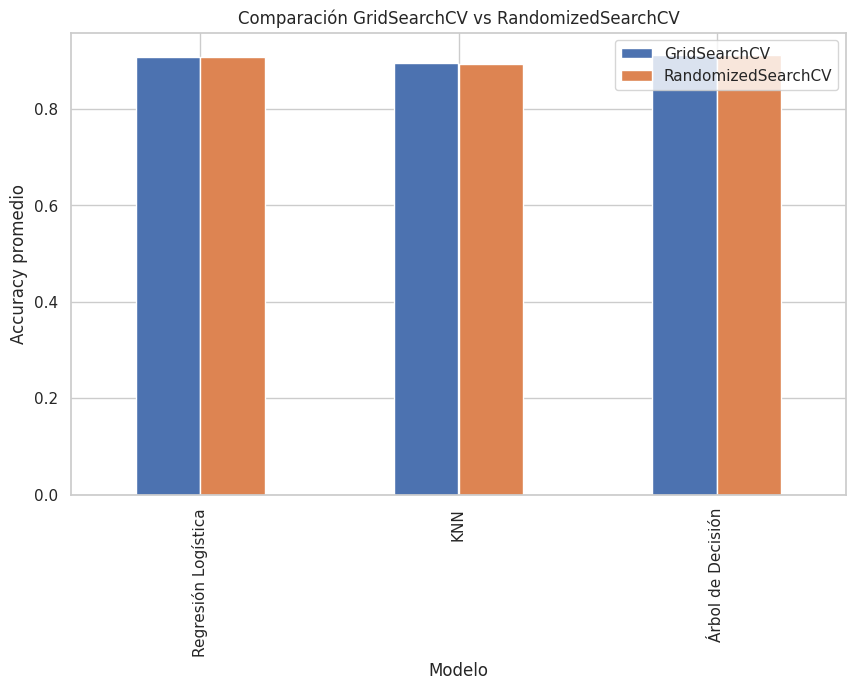

In [80]:
resultados_opt.set_index('Modelo').plot(kind='bar',figsize=(10,6))

plt.title('Comparación GridSearchCV vs RandomizedSearchCV')
plt.ylabel('Accuracy promedio')
plt.grid(True)

plt.show()

In [81]:
# Mejor modelo final
print("Mejor GridSearchCV:")
print(resultados_opt[['Modelo','GridSearchCV']])

print("Mejor RandomizedSearchCV:")
print(resultados_opt[['Modelo','RandomizedSearchCV']])

Mejor GridSearchCV:
                Modelo  GridSearchCV
0  Regresión Logística      0.908337
1                  KNN      0.895226
2    Árbol de Decisión      0.913001
Mejor RandomizedSearchCV:
                Modelo  RandomizedSearchCV
0  Regresión Logística            0.908337
1                  KNN            0.893357
2    Árbol de Decisión            0.913001


Se aplicaron las técnicas GridSearchCV y RandomizedSearchCV para optimizar los hiperparámetros de los modelos de Regresión Logística, KNN y Árbol de Decisión. Los resultados muestran que el Árbol de Decisión obtuvo el mejor desempeño en ambos métodos, alcanzando un Accuracy promedio de 91,30%, superando a la Regresión Logística (90,83%) y KNN (89,52%).

Además, los resultados de GridSearchCV y RandomizedSearchCV fueron prácticamente idénticos para la Regresión Logística y el Árbol de Decisión, mientras que en KNN la diferencia fue mínima (89,52% vs 89,34%). Esto indica que RandomizedSearchCV logró encontrar soluciones muy similares a GridSearchCV utilizando menos combinaciones de hiperparámetros y, por lo tanto, con un menor costo computacional.

En conclusión, el Árbol de Decisión optimizado fue seleccionado como el mejor modelo del proyecto, ya que alcanzó el mayor Accuracy mediante validación cruzada y mostró estabilidad en ambos métodos de optimización. Estos resultados sugieren que las relaciones presentes en los datos pueden ser capturadas eficazmente mediante reglas de decisión no lineales.

**5. Evaluación de Modelos:**

5.1. Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.

5.2. Generar y analizar la matriz de confusión para los modelos optimizados.

5.3. Crear y visualizar la curva ROC para evaluar la capacidad del modelo para distinguir entre clases.

In [82]:
# 5.1. Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [83]:
# Regresión Logística Optimizada
y_pred_lr = grid_lr.predict(X_test)

print('REGRESIÓN LOGÍSTICA')
print('Accuracy:',accuracy_score(y_test, y_pred_lr))
print('Precision:',precision_score(y_test, y_pred_lr))
print('Recall:',recall_score(y_test, y_pred_lr))
print('F1-Score:',f1_score(y_test, y_pred_lr))

REGRESIÓN LOGÍSTICA
Accuracy: 0.914179104477612
Precision: 0.9111111111111111
Recall: 0.917910447761194
F1-Score: 0.9144981412639405


In [84]:
# KNN Optimizado
y_pred_knn = grid_knn.predict(X_test)

print('KNN')
print('Accuracy:',accuracy_score(y_test, y_pred_knn))
print('Precision:',precision_score(y_test, y_pred_knn))
print('Recall:',recall_score(y_test, y_pred_knn))
print('F1-Score:',f1_score(y_test, y_pred_knn))

KNN
Accuracy: 0.8955223880597015
Precision: 0.9206349206349206
Recall: 0.8656716417910447
F1-Score: 0.8923076923076924


In [85]:
# Árbol de Decisión Optimizado
y_pred_tree = grid_tree.predict(X_test)

print('ÁRBOL DE DECISIÓN')
print('Accuracy:',accuracy_score(y_test, y_pred_tree))
print('Precision:',precision_score(y_test, y_pred_tree))
print('Recall:',recall_score(y_test, y_pred_tree))
print('F1-Score:',f1_score(y_test, y_pred_tree))

ÁRBOL DE DECISIÓN
Accuracy: 0.9216417910447762
Precision: 0.9448818897637795
Recall: 0.8955223880597015
F1-Score: 0.9195402298850575


In [87]:
# Tabla Comparativa
resultados = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'KNN',
        'Árbol de Decisión'
    ],
    'Accuracy': [
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_knn),
        precision_score(y_test,y_pred_tree)
    ],
    'Recall': [
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_knn),
        recall_score(y_test,y_pred_tree)
    ],
    'F1-Score': [
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_knn),
        f1_score(y_test,y_pred_tree)]})

display(resultados)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.914179,0.911111,0.917910,0.914498
1,KNN,0.895522,0.920635,0.865672,0.892308
2,Árbol de Decisión,0.921642,0.944882,0.895522,0.919540


In [88]:
# 5.2. Generar y analizar la matriz de confusión para los modelos optimizados.
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay



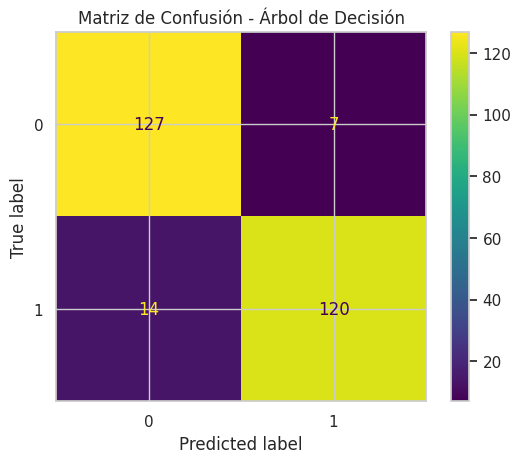

In [89]:
cm = confusion_matrix(y_test,y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Matriz de Confusión - Árbol de Decisión')

plt.show()